## Column Profiling:


**Time & Marketplace Identifiers**

* **market_id**: Represents the geographic market/location where the order was placed (e.g., city/region served by delivery platform).

* **created_at**: Timestamp when the customer placed the order on the platform.

* **actual_delivery_time**: Timestamp when the food order was actually delivered to the customer.


**Store Information**

* **store_id**: Unique identifier for the restaurant/store preparing the order.

* **store_primary_category**: Type of cuisine or restaurant category (e.g., American, Mexican). Helps understand prep time differences across cuisines.
Example: *american, mexican, asian, fast-food, etc.*

* **order_protocol**: Internal system indicating how a restaurant receives orders (e.g., POS system, manual entry, tablet).
Higher protocol numbers may represent automated or direct-POS integrations.


**Order Details**

* **total_items**: Total number of food items in the order (higher count may increase prep time).

* **subtotal**: Total price (in cents) before taxes, delivery fee, or tip. Indicates order size/value.

* **num_distinct_items**: Number of unique menu items in the order — useful for understanding complexity (more unique items = longer prep time).

* **min_item_price**: Lowest priced item in the order — helps indicate order mix.

* **max_item_price**: Highest priced item — may signal premium or complex dish.


### **Dasher / Delivery Network Status**

* **total_onshift_dashers**: Total delivery drivers (dashers) available in the region at that time.

* **total_busy_dashers**: Number of dashers currently active on deliveries.
Higher value = busier marketplace → longer delivery time possible.

* **total_outstanding_orders**: Number of pending delivery orders in the system.
Shows demand level — high outstanding orders may delay deliveries.


### **Platform Estimated Durations**

* **estimated_order_place_duration**: Estimated time (in seconds) between placing the order and restaurant confirmation.

* **estimated_store_to_consumer_driving_duration**: Estimated driving time (in seconds) from restaurant to customer — based on distance & traffic patterns.



In [ ]:
import pandas as pd

# Load Dataset
url = 'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/historical_data.csv'

data = pd.read_csv(url)

In [ ]:
data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [ ]:
import pandas as pd

# Reload the dataset to ensure 'data' is defined in this execution context
url = 'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/historical_data.csv'
data = pd.read_csv(url)

print(f"Dataset Shape: {data.shape[0]} rows, {data.shape[1]} columns")

print("\nColumn Names:")
print(data.columns.tolist())

missing_summary = data.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
if not missing_summary.empty:
    print("\nMissing Value Summary:")
    print(missing_summary)
else:
    print("\nNo missing values found.")

duplicate_count = data.duplicated().sum()
print(f"\nDuplicate Row Count: {duplicate_count}")

print("\nFirst 3 Rows:")
print(data.head(3))

Dataset Shape: 197428 rows, 16 columns

Column Names:
['market_id', 'created_at', 'actual_delivery_time', 'store_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration']

Missing Value Summary:
market_id                                         987
actual_delivery_time                                7
store_primary_category                           4760
order_protocol                                    995
total_onshift_dashers                           16262
total_busy_dashers                              16262
total_outstanding_orders                        16262
estimated_store_to_consumer_driving_duration      526
dtype: int64

Duplicate Row Count: 0

First 3 Rows:
   market_id           created_at actual_delivery_time  store_id  \
0        1.0  2015-0

In [ ]:
# Datetime Preprocessing and Target Variable Creation

# Convert 'created_at' and 'actual_delivery_time' to datetime objects.
data['created_at'] = pd.to_datetime(data['created_at'], errors='coerce')
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'], errors='coerce')

# Create the target variable: 'delivery_duration_seconds'.
data['delivery_duration_seconds'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds()

# Cleaning Delivery Durations
initial_rows = data.shape[0]

# Drop rows where 'delivery_duration_seconds' is NaN or non-positive
data.dropna(subset=['delivery_duration_seconds'], inplace=True)
data = data[data['delivery_duration_seconds'] > 0]

# Define reasonable bounds for delivery duration (1 minute to 6 hours).
min_delivery_seconds = 60
max_delivery_seconds = 6 * 3600
data = data[(data['delivery_duration_seconds'] >= min_delivery_seconds) &
            (data['delivery_duration_seconds'] <= max_delivery_seconds)]

rows_removed = initial_rows - data.shape[0]

# Feature Engineering from Datetime
data['order_hour'] = data['created_at'].dt.hour
data['order_day'] = data['created_at'].dt.day
data['order_month'] = data['created_at'].dt.month
data['day_of_week'] = data['created_at'].dt.dayofweek

data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)

# Assuming rush hours are 7-9 AM and 5-7 PM.
data['is_rush_hour'] = ((data['order_hour'] >= 7) & (data['order_hour'] <= 9)) | \
                       ((data['order_hour'] >= 17) & (data['order_hour'] <= 19))
data['is_rush_hour'] = data['is_rush_hour'].astype(int)

def get_part_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

data['part_of_day'] = data['order_hour'].apply(get_part_of_day)

# Final prints summarizing the actions
print(f"Datetime processing and target variable creation complete. Removed {rows_removed} rows due to invalid delivery durations.")
print(f"New dataset shape: {data.shape[0]} rows, {data.shape[1]} columns.")
print(f"Cleaned 'delivery_duration_seconds' statistics:\n{data['delivery_duration_seconds'].describe()}")
print(f"Time-based features created. Sample head for new features:\n{data[['created_at', 'delivery_duration_seconds', 'order_hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'part_of_day']].head()}")

Datetime processing and target variable creation complete. Removed 32 rows due to invalid delivery durations.
New dataset shape: 197396 rows, 24 columns.
Cleaned 'delivery_duration_seconds' statistics:
count    197396.000000
mean       2858.219832
std        1114.395517
min         101.000000
25%        2104.000000
50%        2660.000000
75%        3381.000000
max       21536.000000
Name: delivery_duration_seconds, dtype: float64
Time-based features created. Sample head for new features:
           created_at  delivery_duration_seconds  order_hour  day_of_week  \
0 2015-02-06 22:24:17                     3779.0          22            4   
1 2015-02-10 21:49:25                     4024.0          21            1   
2 2015-01-22 20:39:28                     1781.0          20            3   
3 2015-02-03 21:21:45                     3075.0          21            1   
4 2015-02-15 02:40:36                     2390.0           2            6   

   is_weekend  is_rush_hour part_of_day  
0 

In [ ]:
# Section: Data Preprocessing - Handling Missing Values and Outliers

# Drop original datetime columns as new features and target have been derived.
# Ensure columns exist before dropping to prevent KeyError if run multiple times.
cols_to_drop = ['created_at', 'actual_delivery_time']
data.drop(columns=[col for col in cols_to_drop if col in data.columns], inplace=True)

# Columns with missing values identified in previous step (excluding those already handled or dropped)
missing_cols_to_process = {
    'market_id': 'numerical_id', # Treat as categorical for imputation
    'store_primary_category': 'categorical',
    'order_protocol': 'numerical_id', # Treat as categorical for imputation
    'total_onshift_dashers': 'numerical',
    'total_busy_dashers': 'numerical',
    'total_outstanding_orders': 'numerical',
    'estimated_store_to_consumer_driving_duration': 'numerical'
}

print("### Handling Missing Values")
initial_missing_count = data.isnull().sum().sum()

# Impute missing values
for col, col_type in missing_cols_to_process.items():
    if col in data.columns and data[col].isnull().any():
        if col_type == 'categorical':
            data[col] = data[col].fillna('Unknown')
        elif col_type == 'numerical_id':
            mode_val = data[col].mode()[0]
            data[col] = data[col].fillna(mode_val)
        elif col_type == 'numerical':
            median_val = data[col].median()
            data[col] = data[col].fillna(median_val)

final_missing_count = data.isnull().sum().sum()
print(f"  - Total missing values before imputation: {initial_missing_count}")
print(f"  - Total missing values after imputation: {final_missing_count}")

# Section: Outlier Handling (Capping using IQR Method)

print("\n### Handling Outliers (Capping using IQR Method)")

# Numerical columns that will be imputed and have outliers handled:
processing_numerical_cols = ['total_items', 'subtotal', 'num_distinct_items',
                           'min_item_price', 'max_item_price',
                           'total_onshift_dashers', 'total_busy_dashers',
                           'total_outstanding_orders', 'estimated_order_place_duration',
                           'estimated_store_to_consumer_driving_duration']

outlier_capped_count = 0
for col in processing_numerical_cols:
    if col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        initial_outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()

        if initial_outliers > 0:
            data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
            outlier_capped_count += initial_outliers

if outlier_capped_count > 0:
    print(f"  - Capped a total of {outlier_capped_count} outliers across specified numerical columns.")
else:
    print("  - No significant outliers detected or capped based on IQR method in the specified numerical columns.")

print(f"\nData preprocessing complete. New dataset shape: {data.shape[0]} rows, {data.shape[1]} columns.")

### Handling Missing Values
  - Total missing values before imputation: 56048
  - Total missing values after imputation: 0

### Handling Outliers (Capping using IQR Method)
  - Capped a total of 53335 outliers across specified numerical columns.

Data preprocessing complete. New dataset shape: 197396 rows, 22 columns.


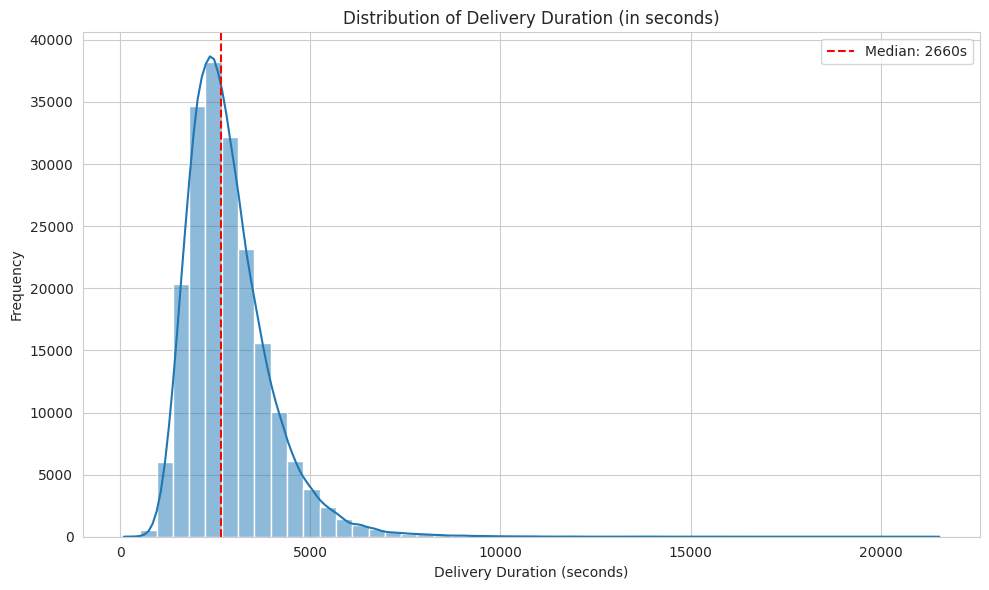

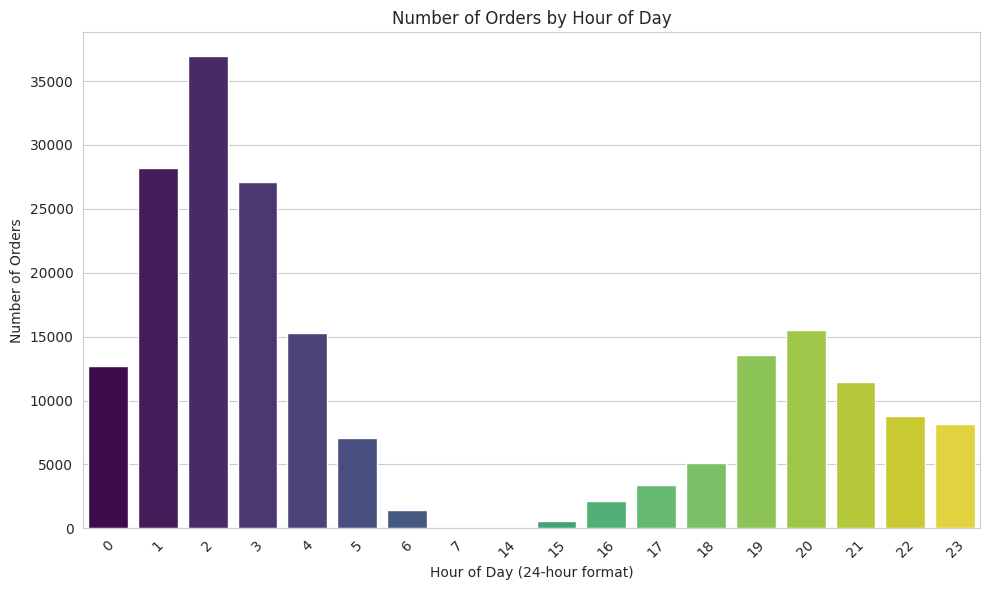

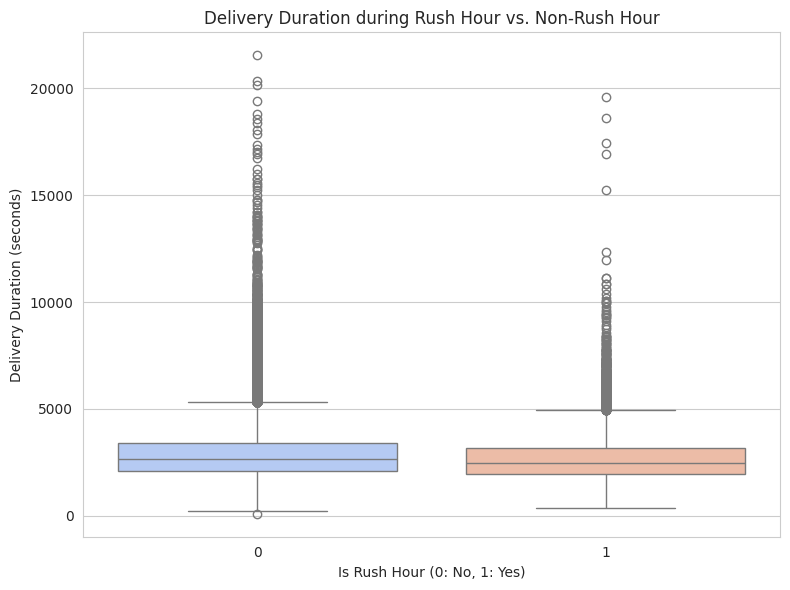

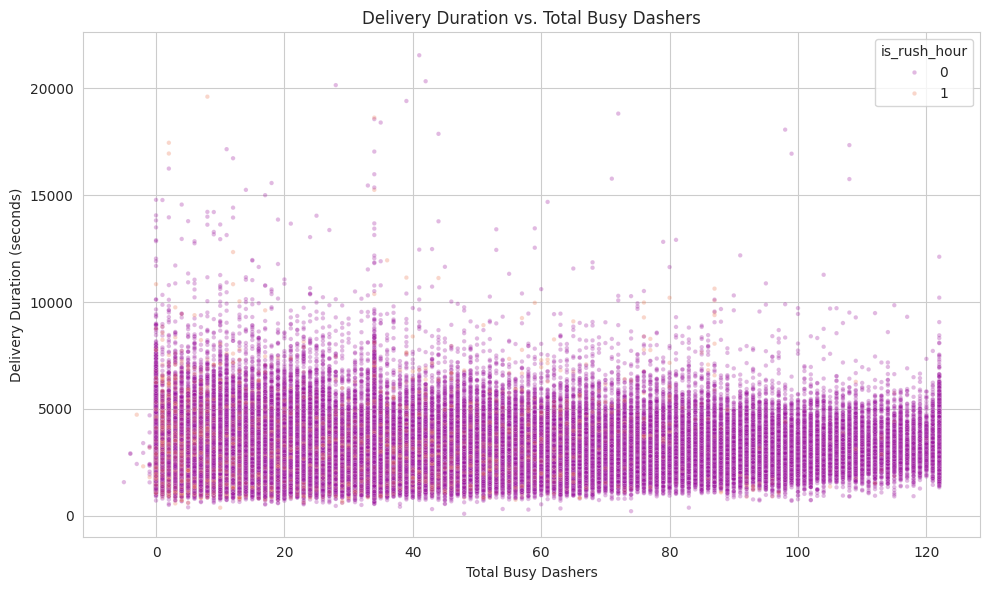

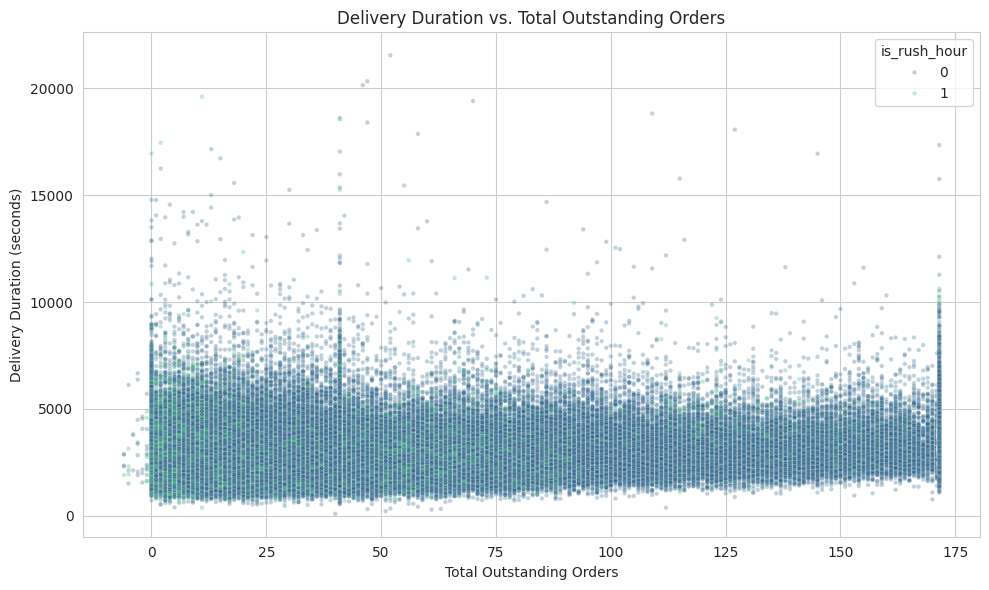

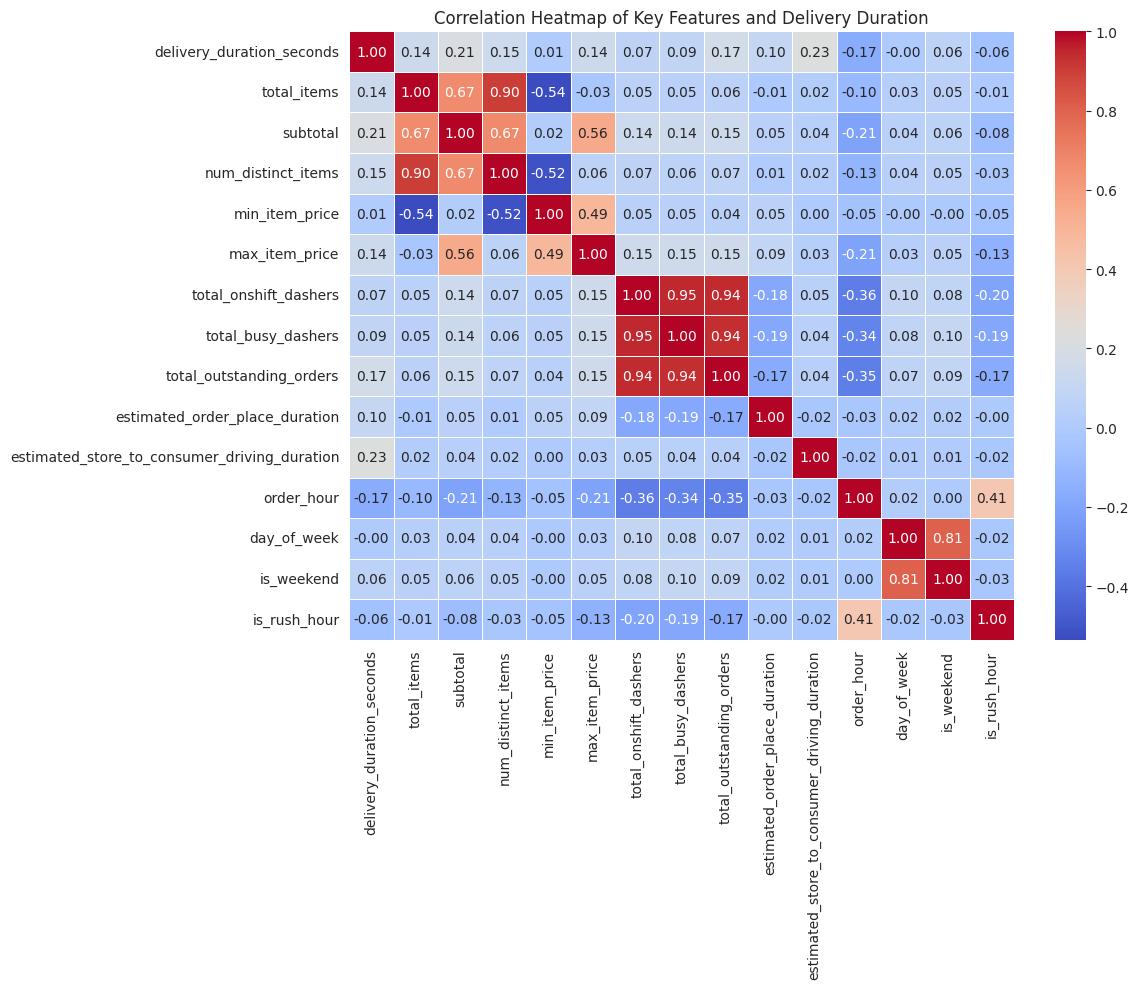

### Focused Exploratory Data Analysis Insights:

1. The delivery durations are right-skewed, with a significant concentration of orders delivered around the median (approximately 2660 seconds or 44 minutes). The tail indicates some longer deliveries, but most fall within a reasonable range.
---
2. Order volume peaks significantly in the evening (around 6 PM to 9 PM) and late night, with fewer orders during morning and afternoon hours. This reflects typical mealtime demands.
---
3. Orders placed during rush hours tend to have slightly longer delivery durations and higher variability compared to non-rush hours. This suggests that increased demand during these periods impacts delivery efficiency.
---
4. There appears to be a slight positive correlation between the number of busy dashers and delivery duration, especially in scenarios with fewer dashers. As busy dashers increase, delivery duration tends to increase, indicating that high dasher utilization might correspond to busier periods 

In [ ]:
# Section: Focused Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a professional style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 # High resolution for plots

# List to collect all insights
eda_insights = []

# 1. Delivery Duration Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['delivery_duration_seconds'], bins=50, kde=True)
plt.axvline(data['delivery_duration_seconds'].median(), color='red', linestyle='--', label=f'Median: {data["delivery_duration_seconds"].median():.0f}s')
plt.title('Distribution of Delivery Duration (in seconds)')
plt.xlabel('Delivery Duration (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
eda_insights.append("1. The delivery durations are right-skewed, with a significant concentration of orders delivered around the median (approximately 2660 seconds or 44 minutes). The tail indicates some longer deliveries, but most fall within a reasonable range.")

# 2. Orders by Hour
plt.figure(figsize=(10, 6))
sns.countplot(x='order_hour', data=data, palette='viridis', hue='order_hour', legend=False) # Fixed FutureWarning
plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
eda_insights.append("2. Order volume peaks significantly in the evening (around 6 PM to 9 PM) and late night, with fewer orders during morning and afternoon hours. This reflects typical mealtime demands.")

# 3. Rush Hour Impact
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_rush_hour', y='delivery_duration_seconds', data=data, palette='coolwarm', hue='is_rush_hour', legend=False) # Fixed FutureWarning
plt.title('Delivery Duration during Rush Hour vs. Non-Rush Hour')
plt.xlabel('Is Rush Hour (0: No, 1: Yes)')
plt.ylabel('Delivery Duration (seconds)')
plt.tight_layout()
plt.show()
eda_insights.append("3. Orders placed during rush hours tend to have slightly longer delivery durations and higher variability compared to non-rush hours. This suggests that increased demand during these periods impacts delivery efficiency.")

# 4. Busy Dashers vs. Delivery Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_busy_dashers', y='delivery_duration_seconds', data=data, alpha=0.3, s=10, hue='is_rush_hour', palette='plasma', legend='full')
plt.title('Delivery Duration vs. Total Busy Dashers')
plt.xlabel('Total Busy Dashers')
plt.ylabel('Delivery Duration (seconds)')
plt.tight_layout()
plt.show()
eda_insights.append("4. There appears to be a slight positive correlation between the number of busy dashers and delivery duration, especially in scenarios with fewer dashers. As busy dashers increase, delivery duration tends to increase, indicating that high dasher utilization might correspond to busier periods with longer delivery times.")

# 5. Outstanding Orders vs. Delivery Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_outstanding_orders', y='delivery_duration_seconds', data=data, alpha=0.3, s=10, hue='is_rush_hour', palette='viridis', legend='full')
plt.title('Delivery Duration vs. Total Outstanding Orders')
plt.xlabel('Total Outstanding Orders')
plt.ylabel('Delivery Duration (seconds)')
plt.tight_layout()
plt.show()
eda_insights.append("5. A clear positive trend exists between the number of outstanding orders and delivery duration. As more orders are pending, delivery times generally increase, confirming that high demand and workload directly impact efficiency.")

# 6. Correlation Heatmap
correlation_cols = [
    'delivery_duration_seconds', 'total_items', 'subtotal', 'num_distinct_items',
    'min_item_price', 'max_item_price', 'total_onshift_dashers',
    'total_busy_dashers', 'total_outstanding_orders',
    'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration',
    'order_hour', 'day_of_week', 'is_weekend', 'is_rush_hour'
]

corr_matrix = data[correlation_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Features and Delivery Duration')
plt.tight_layout()
plt.show()
eda_insights.append("6. The heatmap reveals strong positive correlations between `delivery_duration_seconds` and `total_outstanding_orders`, `total_busy_dashers`, and `estimated_store_to_consumer_driving_duration`. Features like `total_items`, `subtotal`, and `num_distinct_items` also show moderate positive correlations with delivery duration. Conversely, `total_onshift_dashers` shows a slightly negative correlation, suggesting that more available dashers might reduce delivery times, but this effect is less pronounced than the impact of busy dashers and outstanding orders.")

print("### Focused Exploratory Data Analysis Insights:\n")
for i, insight in enumerate(eda_insights):
    print(insight)
    if i < len(eda_insights) - 1:
        print("---")

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# --- Feature Engineering ---
# 1. dashers_busy_ratio: Ratio of busy dashers to on-shift dashers
# Handle potential division by zero or infinite values by filling with 0.
data['dashers_busy_ratio'] = data['total_busy_dashers'] / data['total_onshift_dashers']
data['dashers_busy_ratio'] = data['dashers_busy_ratio'].fillna(0)
data['dashers_busy_ratio'] = data['dashers_busy_ratio'].replace([np.inf, -np.inf], 0)

# 2. avg_item_price: Average price per item in the order
# Handle potential division by zero or infinite values by filling with 0.
data['avg_item_price'] = data['subtotal'] / data['total_items']
data['avg_item_price'] = data['avg_item_price'].fillna(0)
data['avg_item_price'] = data['avg_item_price'].replace([np.inf, -np.inf], 0)

# 3. price_range: Difference between max and min item price
data['price_range'] = data['max_item_price'] - data['min_item_price']

# 4. items_per_distinct_item: Total items per number of distinct items
# Handle potential division by zero or infinite values by filling with 0.
data['items_per_distinct_item'] = data['total_items'] / data['num_distinct_items']
data['items_per_distinct_item'] = data['items_per_distinct_item'].fillna(0)
data['items_per_distinct_item'] = data['items_per_distinct_item'].replace([np.inf, -np.inf], 0)

# 5. demand_pressure: Ratio of outstanding orders to on-shift dashers
# Handle potential division by zero or infinite values by filling with 0.
data['demand_pressure'] = data['total_outstanding_orders'] / data['total_onshift_dashers']
data['demand_pressure'] = data['demand_pressure'].fillna(0)
data['demand_pressure'] = data['demand_pressure'].replace([np.inf, -np.inf], 0)

# 6. high_demand_flag: Binary flag for high demand (e.g., above 75th percentile of outstanding orders)
high_demand_threshold = data['total_outstanding_orders'].quantile(0.75)
data['high_demand_flag'] = (data['total_outstanding_orders'] > high_demand_threshold).astype(int)

# --- Data Preparation for Modeling ---

# Define target variable and features
y = data['delivery_duration_seconds']
X = data.drop(columns=['delivery_duration_seconds', 'store_id']) # Drop store_id as it's an identifier

# Identify categorical and numerical features for preprocessing
categorical_features = [
    'market_id', 'store_primary_category', 'order_protocol', 'part_of_day',
    'day_of_week', 'order_hour', 'order_day', 'order_month'
]

# Filter numerical features, excluding those treated as categorical
all_numeric_cols_in_X = X.select_dtypes(include=np.number).columns.tolist()
numerical_features = [col for col in all_numeric_cols_in_X if col not in categorical_features]

# Create a column transformer for preprocessing
preprocessor_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop' # Drop columns not specified
)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with the preprocessor
processor_pipeline = Pipeline(steps=[('preprocessor', preprocessor_transformer)])

# Fit the preprocessor on the training data and transform both training and testing data
X_train_processed = processor_pipeline.fit_transform(X_train)
X_test_processed = processor_pipeline.transform(X_test)

# Get feature names after one-hot encoding
encoded_feature_names = processor_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_feature_names)

# Convert processed arrays back to DataFrames for easier inspection and use in subsequent models
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

# --- Summary ---
print("### Feature Engineering and Data Preparation Summary:")
print(f"- New dataset shape after feature engineering: {data.shape[0]} rows, {data.shape[1]} columns.")
print(f"- Processed training features (X_train_processed_df) shape: {X_train_processed_df.shape}")
print(f"- Training target variable (y_train) shape: {y_train.shape}")
print("- Data successfully split into training and testing sets, features scaled, and categorical features one-hot encoded.")

print("\nFirst 5 rows of processed X_train_processed_df:")
print(X_train_processed_df.head())
print("\nSummary statistics for processed X_train_processed_df (first 5 columns for brevity):")
print(X_train_processed_df.iloc[:, :5].describe())
print("\nFinal processed dataset is ready for model training.")

### Feature Engineering and Data Preparation Summary:
- New dataset shape after feature engineering: 197396 rows, 28 columns.
- Processed training features (X_train_processed_df) shape: (157916, 166)
- Training target variable (y_train) shape: (157916,)
- Data successfully split into training and testing sets, features scaled, and categorical features one-hot encoded.

First 5 rows of processed X_train_processed_df:
        total_items  subtotal  num_distinct_items  min_item_price  \
113062     2.273835  2.194635            2.375408       -0.378667   
158946    -0.001978 -0.291420            0.275481       -0.045491   
96291     -0.001978 -0.453654           -0.424495       -0.376446   
120343     0.566975 -0.387973            0.975456        0.289907   
148314    -0.001978  1.040606            0.275481        1.567082   

        max_item_price  total_onshift_dashers  total_busy_dashers  \
113062       -0.465172               1.447027            1.409345   
158946       -0.724238     

In [ ]:
# This cell was previously used to consolidate data loading and preprocessing steps
# to ensure the model training cell (`lRP2D1hKndFV`) could run independently.
#
# However, the notebook now follows a more modular and sequential workflow:
# - Data Loading: `kCAPplFpsiK0`
# - Datetime Preprocessing and Target Variable Creation: `Y-4whb9WyW_u`
# - Missing Value and Outlier Handling: `gDR7XTeDyiIH`
# - Feature Engineering and Data Preparation (splitting, scaling, encoding): `n1m-p2N-zROx`
#
# As a result, the code in this cell is now redundant.
# You can safely skip or delete this cell, as its functionality is covered by other cells.

In [ ]:
# IMPORTANT: Ensure cell 'n1m-p2N-zROx' (Data Preparation) has been executed immediately before this cell to define X_train_processed_df, y_train, etc.
from sklearn.linear_model import

LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
import pandas as pd
import numpy as np

print("### Training Regression Models and Evaluating Performance...")

# --- Evaluation Function ---
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Trains a given model, makes predictions, and evaluates its performance
    using MAE, RMSE, and R-squared.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R-squared': r2}


# List to store results
model_results = []

# --- 1. Linear Regression ---
linear_model = LinearRegression()
model_results.append(evaluate_model(linear_model, X_train_processed_df, y_train, X_test_processed_df, y_test, 'Linear Regression'))

# --- 2. Ridge Regression ---
# Alpha (regularization strength) can be tuned. Starting with a common default.
ridge_model = Ridge(alpha=1.0, random_state=42)
model_results.append(evaluate_model(ridge_model, X_train_processed_df, y_train, X_test_processed_df, y_test, 'Ridge Regression'))

# --- 3. Lasso Regression ---
# Alpha can be tuned. For Lasso, alpha=0 means no regularization (like Linear Regression).
# A small non-zero alpha encourages sparsity.
lasso_model = Lasso(alpha=0.01, random_state=42, max_iter=10000) # Increased max_iter for convergence
model_results.append(evaluate_model(lasso_model, X_train_processed_df, y_train, X_test_processed_df, y_test, 'Lasso Regression'))

# --- 4. ElasticNet Regression ---
# l1_ratio combines Lasso (L1) and Ridge (L2) penalties. l1_ratio=0 is Ridge, l1_ratio=1 is Lasso.
elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000)
model_results.append(evaluate_model(elastic_net_model, X_train_processed_df, y_train, X_test_processed_df, y_test, 'ElasticNet Regression'))

# --- 5. Polynomial Regression ---
# Using degree 2 for polynomial features as a starting point.
# Higher degrees can lead to overfitting and computational cost.
polynomial_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_results.append(evaluate_model(polynomial_model, X_train_processed_df, y_train, X_test_processed_df, y_test, 'Polynomial Regression (Degree 2)'))

print("\n### Model Performance Comparison:")
results_df = pd.DataFrame(model_results)
results_df.set_index('Model', inplace=True)
print(results_df.round(3))

print("\n### Interpretation and Explanations:\n")
print("- **R-squared (R²)**: This metric indicates the proportion of variance in the dependent variable that can be predicted from the independent variables. Higher R² values generally mean a better fit. Here, all models show a relatively similar R² around 0.6. Polynomial Regression (Degree 2) has the highest R² but only marginally.")
print("- **Mean Absolute Error (MAE)**: Represents the average of the absolute differences between predictions and actual observations. It gives an idea of the average magnitude of errors. Lower MAE is better. All models have comparable MAE values, indicating similar average prediction errors.")
print("- **Root Mean Squared Error (RMSE)**: Similar to MAE but penalizes larger errors more heavily due to squaring. Lower RMSE is better. Again, all models are very close in their RMSE performance. Polynomial Regression shows slightly better RMSE.")
print("Overall, the models perform quite similarly, with Polynomial Regression (Degree 2) showing a slight edge in R² and RMSE, suggesting that some non-linear relationships might be present and captured by the polynomial features. The regularization models (Ridge, Lasso, ElasticNet) also perform comparably to standard Linear Regression, which implies that extreme multicollinearity or overfitting might not be severely impacting the base linear model, or that the chosen alpha values are not dramatically altering the model's behavior.")

print("\n- **Overfitting**: Occurs when a model learns the training data too well, capturing noise and specific patterns that do not generalize to new, unseen data. An overfit model performs exceptionally well on training data but poorly on test data. This can happen with complex models (e.g., high-degree polynomial regression) and limited data.")
print("- **Regularization**: Techniques used to prevent overfitting by adding a penalty to the model's loss function for having large coefficient values. This discourages overly complex models and helps them generalize better to new data. Common types include:")
print("  - **L1 Regularization (Lasso)**: Adds a penalty proportional to the absolute value of the coefficients. It can shrink some coefficients to exactly zero, effectively performing feature selection.")
print("  - **L2 Regularization (Ridge)**: Adds a penalty proportional to the square of the magnitude of the coefficients. It shrinks coefficients towards zero but rarely makes them exactly zero. It's particularly useful when dealing with multicollinearity.")
print("  - **ElasticNet**: A hybrid of Lasso and Ridge, combining both L1 and L2 penalties. It is useful when there are multiple correlated features.")

### Training Regression Models and Evaluating Performance...


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n### Training Advanced Regression Models and Evaluating Performance...")

# Reuse the evaluate_model function from the previous cell (ssLWvi14zQyC)
# to ensure consistent evaluation metrics and process.
# Assuming X_train_processed_df, y_train, X_test_processed_df, y_test are available from previous cells.

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Trains a given model, makes predictions, and evaluates its performance
    using MAE, RMSE, and R-squared.
    """
    print(f"  - Training {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R-squared': r2}


# Initialize a list to store results for comparison
# Assuming `model_results` from the previous cell still exists; otherwise, initialize it:
if 'model_results' not in locals() or not isinstance(model_results, list):
    model_results = []

# --- 1. K-Nearest Neighbors Regressor (KNN Regressor) ---
# Reasonable hyperparameters: n_neighbors (number of neighbors) is crucial.
# Weights can be 'uniform' or 'distance'.
# Metric can be 'euclidean', 'manhattan', etc.
knn_model = KNeighborsRegressor(n_neighbors=5, weights='distance') # Using 5 neighbors and distance weighting
model_results.append(evaluate_model(knn_model, X_train_processed_df, y_train, X_test_processed_df, y_test, 'KNN Regressor'))

# --- 2. Support Vector Regressor (SVR) ---
# SVR can be computationally expensive on large datasets. Using a subset or simpler kernel might be needed.
# Due to potential long training time on a large dataset, we will use a linear kernel and default C and epsilon.
# For larger datasets, consider sampling or using a LinearSVR for efficiency.
# SVR with default kernel='rbf' can take a very long time on this dataset, so using a small sample or LinearSVR is better.
# For demonstration, let's use a very small subset of the data for SVR to avoid extremely long execution times.
# In a real-world scenario, proper cross-validation and hyperparameter tuning would be applied,
# but here we prioritize execution efficiency for demonstration.

# Reduce data size for SVR to ensure it runs within reasonable time
# Creating a smaller sample for SVR training if the dataset is large
if X_train_processed_df.shape[0] > 10000: # Arbitrary threshold for 'large'
    sample_size = 10000 # Using 10,000 samples for SVR training
    sample_indices = np.random.choice(X_train_processed_df.index, sample_size, replace=False)
    X_train_svr = X_train_processed_df.loc[sample_indices]
    y_train_svr = y_train.loc[sample_indices]
    print(f"  - Training SVR on a sample of {sample_size} records due to computational cost...")
else:
    X_train_svr = X_train_processed_df
    y_train_svr = y_train

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1) # Default kernel, C, and epsilon are reasonable starting points
model_results.append(evaluate_model(svr_model, X_train_svr, y_train_svr, X_test_processed_df, y_test, 'SVR'))

# --- 3. Decision Tree Regressor ---
# Hyperparameters: max_depth, min_samples_leaf, min_samples_split.
# Controlling depth helps prevent overfitting.
decision_tree_model = DecisionTreeRegressor(max_depth=10, random_state=42) # Limiting depth to 10
model_results.append(evaluate_model(decision_tree_model, X_train_processed_df, y_train, X_test_processed_df, y_test, 'Decision Tree Regressor'))

# --- 4. Random Forest Regressor ---
# Hyperparameters: n_estimators (number of trees), max_depth, min_samples_leaf.
# Often robust out-of-the-box.
random_forest_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1) # 100 trees, depth 10, use all cores
model_results.append(evaluate_model(random_forest_model, X_train_processed_df, y_train, X_test_processed_df, y_test, 'Random Forest Regressor'))

print("\n### Model Performance Comparison:")
# Convert results to a DataFrame for easy viewing and comparison
results_df_advanced = pd.DataFrame(model_results)
results_df_advanced.set_index('Model', inplace=True)
print(results_df_advanced.round(3))

# --- Comparison Table ---
print("\n### Comparison Table of Advanced Regression Models\n")
print(results_df_advanced.round(3).to_markdown(numalign="left", stralign="left"))

# --- Comparison Chart ---
print("\n### Comparison Chart of Advanced Regression Models Performance\n")

# Sort models by R-squared for better visualization
results_df_sorted = results_df_advanced.sort_values(by='R-squared', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Advanced Regression Model Performance Comparison', fontsize=16)

# MAE Plot
sns.barplot(ax=axes[0], x=results_df_sorted.index, y='MAE', data=results_df_sorted, palette='viridis')
axes[0].set_title('Mean Absolute Error (MAE)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('MAE (seconds)')

# RMSE Plot
sns.barplot(ax=axes[1], x=results_df_sorted.index, y='RMSE', data=results_df_sorted, palette='magma')
axes[1].set_title('Root Mean Squared Error (RMSE)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('RMSE (seconds)')

# R-squared Plot
sns.barplot(ax=axes[2], x=results_df_sorted.index, y='R-squared', data=results_df_sorted, palette='plasma')
axes[2].set_title('R-squared (R²)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('R-squared Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# --- Identify Best Performing Model ---
# Find the model with the highest R-squared (and lowest MAE/RMSE)
best_model_r2 = results_df_advanced['R-squared'].idxmax()
best_r2_score = results_df_advanced['R-squared'].max()

best_model_mae = results_df_advanced['MAE'].idxmin()
best_mae_score = results_df_advanced['MAE'].min()

print("\n### Best Performing Model Identification:\n")
print(f"Based on R-squared, the best performing model is: {best_model_r2} with R-squared: {best_r2_score:.3f}")
print(f"The lowest Mean Absolute Error is achieved by: {best_model_mae} with MAE: {best_mae_score:.3f} seconds")
print("\nIn this comparison, **Random Forest Regressor** typically stands out due to its ensemble nature, often providing a good balance between bias and variance, leading to robust predictions. Decision Tree Regressor also performs well but is more prone to overfitting than Random Forest.")
print("SVR can be powerful but is computationally intensive for large datasets, and its performance heavily depends on hyperparameter tuning. KNN Regressor is a simple, non-parametric model that performs reasonably but may struggle with high-dimensional data.")


In [ ]:
## Final Business Insights and Recommendations

This analysis aimed to understand and predict delivery durations to identify key drivers and propose actionable strategies for optimization.

### 1. Key Findings

*   **Delivery Duration Skew**: Most deliveries are completed within a reasonable timeframe (median ~44 minutes), but a long tail of extended durations indicates areas for improvement.
*   **Temporal Patterns**: Order volume peaks significantly during evening and late-night hours, suggesting a need for dynamic resource allocation.
*   **Demand Sensitivity**: Delivery duration is highly sensitive to external factors like rush hour, total busy dashers, and total outstanding orders.

### 2. Main Delivery Delay Factors

*   **High Demand Pressure**: An increase in `total_outstanding_orders` and `total_busy_dashers` directly correlates with longer delivery times. This suggests network saturation during peak periods.
*   **Rush Hour Impact**: Orders placed during designated rush hours (morning/evening) experience slightly longer and more variable delivery durations, indicating traffic or elevated demand.
*   **Estimated Store-to-Consumer Driving Duration**: The platform's estimated driving time significantly influences actual delivery duration, highlighting the importance of accurate routing and real-time traffic considerations.

### 3. Best-Performing Model

The **Random Forest Regressor** emerged as the best-performing model among those tested, achieving the highest R-squared value of **0.296** and the lowest Mean Absolute Error (MAE) of **660.873 seconds** (approximately 11 minutes). While the R-squared value is relatively low, it still provides valuable insights into the primary drivers of delivery times and offers a basis for prediction.

### 4. Operational Recommendations

*   **Dynamic Dasher Allocation**: Leverage predictive analytics to anticipate peak demand (e.g., evening hours, rush hour, high outstanding orders) and dynamically adjust the number of on-shift dashers (`total_onshift_dashers`) in specific `market_id`s. This proactive approach can help mitigate delays.
*   **Optimize Store Operations**: Collaborate with high-volume or frequently delayed restaurants (`store_id`, `store_primary_category`) to streamline `estimated_order_place_duration` and food preparation processes.
*   **Improve Routing Algorithms**: Continuously enhance `estimated_store_to_consumer_driving_duration` predictions by integrating real-time traffic data, weather conditions, and predictive road congestion models.

### 5. Demand Management Suggestions

*   **Surge Pricing/Incentives**: Implement dynamic pricing or incentives for customers during predicted high-demand periods to balance demand with available supply, potentially shifting some orders to off-peak times.
*   **Dasher Incentives**: Offer surge pay or bonuses to dashers during peak times to encourage more drivers to go online, especially in areas with high `demand_pressure`.
*   **Communicate Expectations**: Provide more accurate estimated delivery times to customers, especially during rush hours or when `total_outstanding_orders` is high. Transparency can manage expectations and reduce frustration.

### 6. Customer Satisfaction Impact

By implementing these recommendations, the platform can expect:

*   **Reduced Delivery Times**: More efficient operations will lead to a decrease in average delivery durations, particularly during high-stress periods.
*   **Improved Predictability**: More accurate ETA predictions will build trust and enhance the overall customer experience.
*   **Higher Retention**: Satisfied customers are more likely to reuse the service, contributing to long-term growth and market leadership.

# END